# Bernoulli Distribution — Quality Inspection Problem

A quality inspector checks a **single motherboard** from a production line.

- Historical defect rate: **5%**
- **Success** = finding a defect → p = 0.05

**Questions:**
1. What is the probability the board is defective?
2. What is the variance of this distribution?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import bernoulli

## 1. Define the Distribution

In [2]:
# Define probability of defect
p = 0.05

# Create Bernoulli distribution object
dist = bernoulli(p)

print(f"Distribution : Bernoulli(p = {p})")
print(f"Outcomes     : 0 = No Defect, 1 = Defect")

Distribution : Bernoulli(p = 0.05)
Outcomes     : 0 = No Defect, 1 = Defect


## 2. Calculate Key Statistics

In [3]:
# Probability of defect (success)
prob_defective = dist.pmf(1)

# Probability of no defect
prob_no_defect = dist.pmf(0)

# Mean and variance using scipy
mean, var = dist.stats(moments='mv')

# Standard deviation
std_dev = np.sqrt(var)

print("======================================")
print("        BERNOULLI DISTRIBUTION        ")
print("======================================")
print(f"  P(Defective)   = {prob_defective:.4f}  ({prob_defective*100:.1f}%)")
print(f"  P(No Defect)   = {prob_no_defect:.4f}  ({prob_no_defect*100:.1f}%)")
print("--------------------------------------")
print(f"  Mean (μ)       = {mean:.4f}")
print(f"  Variance (σ²)  = {var:.4f}")
print(f"  Std Dev  (σ)   = {std_dev:.4f}")
print("======================================")

        BERNOULLI DISTRIBUTION        
  P(Defective)   = 0.0500  (5.0%)
  P(No Defect)   = 0.9500  (95.0%)
--------------------------------------
  Mean (μ)       = 0.0500
  Variance (σ²)  = 0.0475
  Std Dev  (σ)   = 0.2179


## 3. Manual Verification

In [4]:
# Manual formula verification
manual_mean     = p
manual_variance = p * (1 - p)

print(f"Manual mean     = p           = {manual_mean}")
print(f"Manual variance = p * (1 - p) = {p} × {1-p} = {manual_variance}")
print(f"\nMatches scipy?  mean={np.isclose(mean, manual_mean)}, var={np.isclose(var, manual_variance)}")

Manual mean     = p           = 0.05
Manual variance = p * (1 - p) = 0.05 × 0.95 = 0.0475

Matches scipy?  mean=True, var=True


## 4. Visualize the PMF

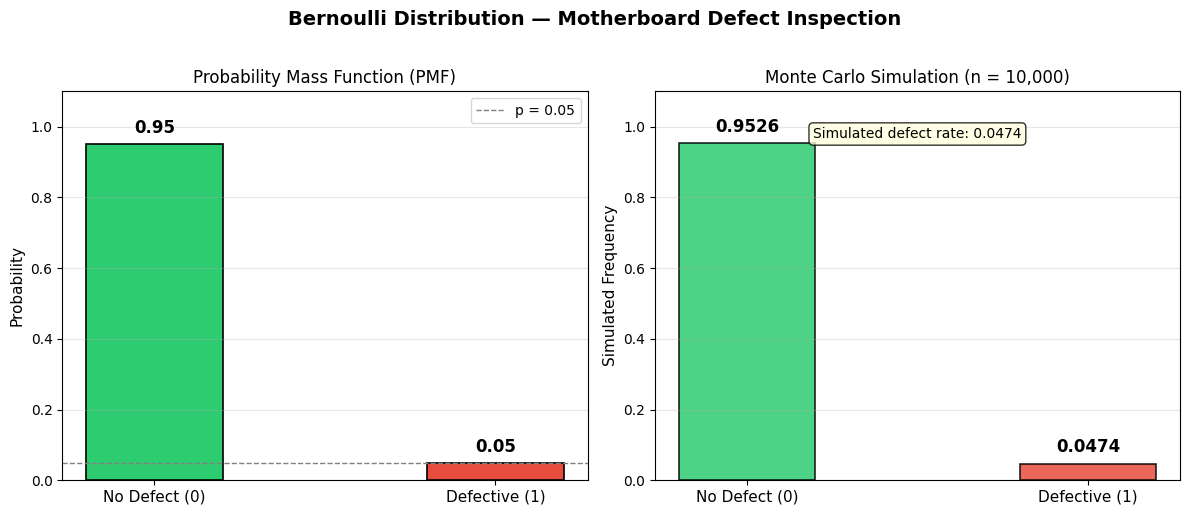

Plot saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Bernoulli Distribution — Motherboard Defect Inspection",
             fontsize=14, fontweight='bold', y=1.02)

outcomes = [0, 1]
probs    = [dist.pmf(x) for x in outcomes]
colors   = ['#2ecc71', '#e74c3c']
labels   = ['No Defect (0)', 'Defective (1)']

# --- Plot 1: PMF Bar Chart ---
bars = axes[0].bar(outcomes, probs, color=colors, width=0.4,
                   edgecolor='black', linewidth=1.2)
axes[0].set_xticks(outcomes)
axes[0].set_xticklabels(['No Defect (0)', 'Defective (1)'], fontsize=11)
axes[0].set_ylabel('Probability', fontsize=11)
axes[0].set_title('Probability Mass Function (PMF)', fontsize=12)
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=p, color='gray', linestyle='--', linewidth=1, label=f'p = {p}')

for bar, prob in zip(bars, probs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{prob:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# --- Plot 2: Simulation ---
np.random.seed(42)
n_simulations = 10000
samples = dist.rvs(size=n_simulations)
sim_defect_rate = samples.mean()

sim_counts = [np.sum(samples == 0), np.sum(samples == 1)]
sim_probs  = [c / n_simulations for c in sim_counts]

bars2 = axes[1].bar(outcomes, sim_probs, color=colors, width=0.4,
                    edgecolor='black', linewidth=1.2, alpha=0.85)
axes[1].set_xticks(outcomes)
axes[1].set_xticklabels(['No Defect (0)', 'Defective (1)'], fontsize=11)
axes[1].set_ylabel('Simulated Frequency', fontsize=11)
axes[1].set_title(f'Monte Carlo Simulation (n = {n_simulations:,})', fontsize=12)
axes[1].set_ylim(0, 1.1)

for bar, prob in zip(bars2, sim_probs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{prob:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[1].text(0.5, 0.88, f'Simulated defect rate: {sim_defect_rate:.4f}',
             transform=axes[1].transAxes, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bernoulli_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 5. Summary

| Property | Formula | Value |
|---|---|---|
| P(Defective) | p | **0.05** |
| P(No Defect) | 1 − p | **0.95** |
| Mean (μ) | p | **0.05** |
| **Variance (σ²)** | p(1 − p) | **0.0475** |
| Std Dev (σ) | √(p(1−p)) | **≈ 0.2179** |

> **Interpretation:** Since we are inspecting a single board (one binary trial), this follows a **Bernoulli distribution**. There is a **5% chance** the board is defective, and the variance of **0.0475** reflects the low uncertainty — outcomes are heavily concentrated at 0 (no defect).